# 02 · Washing-machine use across REFIT homes

**Requirement 2 of the brief.** Using the *official cleaned* REFIT data at 1-minute resolution,
describe washing-machine (WM) availability and data quality, define and apply an explicit
cycle rule, and describe usage patterns and cycle characteristics across homes.

| | |
|---|---|
| **Input** | `data/parquet/clean_house{N}_1min.parquet` (built by `scripts/prepare_data.py` from `CLEAN_REFIT_081116.7z`, mapped to true UTC per house, see notebook 01 §11) |
| **Output** | `artifacts/tables/nb02_*` (coverage, cycles, per-home statistics, sensitivity), `artifacts/figures/nb02_*`, `artifacts/metrics/nb02_summary.json` |
| **Code** | `src/refit_nilm/cycles.py` (rule + tests in `tests/test_cycles_metrics.py`) |
| **Run time** | about 1 minute |

**Time zone.** All series are stored in UTC. Hour-of-day and day-of-week are computed in
Europe/London local time, because laundry habits follow the household clock.

In [1]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from refit_nilm import cycles, io, plots
from refit_nilm import config as C

warnings.filterwarnings("ignore", category=FutureWarning)
plots.setup()
pd.set_option("display.width", 160, "display.max_columns", 30)
P = plots.PALETTE
SUMMARY: dict = {}

amap = io.parse_appliance_map(C.DATA_DIR / "CLEAN_READ_ME_081116.txt")
WM = io.washing_machine_channels(amap)
WD = io.washer_dryer_channels(amap)
PV_HOUSES = [3, 11, 21]  # solar PV in the aggregate (Murray et al. 2017)
APPLIANCE_CHANGES = {13: "washing machine changed 25 Mar 2015"}

# One "machine" per WM channel; House 4 has two washing machines in use at the same time.
MACHINES = []
for h, chans in WM.items():
    for k, ch in enumerate(chans):
        MACHINES.append({"machine": f"H{h}" + (f"-{k + 1}" if len(chans) > 1 else ""), "house": h, "channel": f"Appliance{ch}"})
MACHINES = pd.DataFrame(MACHINES)
print("houses with a washing-machine channel:", sorted(MACHINES.house.unique()), "| without:", [h for h in C.HOUSES if not WM[h]])
MACHINES.T

houses with a washing-machine channel: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(13), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21)] | without: [12]


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
machine,H1,H2,H3,H4-1,H4-2,H5,H6,H7,H8,H9,H10,H11,H13,H15,H16,H17,H18,H19,H20,H21
house,1,2,3,4,4,5,6,7,8,9,10,11,13,15,16,17,18,19,20,21
channel,Appliance5,Appliance2,Appliance6,Appliance4,Appliance5,Appliance3,Appliance2,Appliance5,Appliance4,Appliance3,Appliance5,Appliance3,Appliance3,Appliance3,Appliance5,Appliance4,Appliance5,Appliance2,Appliance4,Appliance3


**Homes included.** 19 of the 20 houses have a washing-machine plug monitor; House 12 has none
(its README lists unidentified "???" channels). House 4 has two washing machines in use over
the same months, so it contributes two machines (`H4-1`, `H4-2`), giving 20 machines in total.
Houses 1, 8, 9 and 18 also own a separate washer-dryer, which matters later because its
signature overlaps the WM's in the aggregate.

## 1. Availability and data quality

**Why.** Before describing behaviour, I need to know how much of each home's record is real
data. In the cleaned release an outage shows up in two ways: (a) no reading at all for a
minute (`n_readings = 0`), and (b) a forward-filled flat line. The README says NaNs were
forward-filled, so short outages can look like a constant aggregate. A real house never
holds exactly the same 1-minute mean for an hour, because the fridge alone cycles every
20–40 minutes; I flag aggregate runs that stay identical for ≥ 60 minutes as suspect.

Columns: `coverage_pct` = minutes with a reading; `missing_intervals` = gaps longer than
3 minutes; `flat_agg_pct` = minutes inside suspect flat runs; `issues_pct` = minutes where the
plug monitors add up to more than the aggregate (README `Issues` flag); `wm_off_pct` = valid
minutes with WM power below 20 W; `wm_exact_zero_pct` = valid minutes with exactly 0 W;
`energy_in_cycles_pct` = share of the channel's energy that falls inside detected cycles
(a check that the cycle rule does not throw away real washing).

In [2]:
def flat_run_mask(x: pd.Series, min_len: int = 60) -> np.ndarray:
    v = x.to_numpy()
    valid = ~np.isnan(v)
    chg = np.r_[True, ~(v[1:] == v[:-1])]
    rid = np.cumsum(chg)
    counts = np.bincount(rid)
    return (counts[rid] >= min_len) & valid


def gap_count(have: pd.Series, min_len: int = 4) -> int:
    edges = np.diff(np.r_[0, (~have).astype(int).to_numpy(), 0])
    starts, ends = np.flatnonzero(edges == 1), np.flatnonzero(edges == -1)
    return int(((ends - starts) >= min_len).sum())


data = {h: io.load_clean_minutes(h) for h in sorted(MACHINES.house.unique())}
rule = cycles.CycleRule()
quality, all_cycles = [], []
for _, r in MACHINES.iterrows():
    m = data[r.house]
    have = m["n_readings"] > 0
    w = m[r.channel].where(have)
    cyc = cycles.detect_cycles(w, rule).assign(machine=r.machine, house=r.house)
    all_cycles.append(cyc)
    valid_days = have.resample("D").mean()
    quality.append(
        {
            "machine": r.machine, "house": r.house, "channel": r.channel,
            "start": m.index.min().date(), "end": m.index.max().date(),
            "span_days": (m.index.max() - m.index.min()).days,
            "coverage_pct": round(100 * have.mean(), 1),
            "days_ge90pct": int((valid_days >= 0.9).sum()),
            "missing_intervals": gap_count(have),
            "flat_agg_pct": round(100 * flat_run_mask(m["Aggregate"].where(have)).mean(), 2),
            "issues_pct": round(100 * m["issues"].mean(), 2),
            "wm_off_pct": round(100 * (w[have] < C.WM_ON_THRESHOLD_W).mean(), 1),
            "wm_exact_zero_pct": round(100 * (w[have] == 0).mean(), 1),
            "cycles": len(cyc),
            "energy_in_cycles_pct": round(100 * cyc["energy_kwh"].sum() / (w.sum() / 60_000), 1),
            "cycles_per_week": round(len(cyc) / (have.sum() / (60 * 24 * 7)), 2),
            "pv": r.house in PV_HOUSES,
            "washer_dryer_too": bool(WD.get(r.house)),
        }
    )
quality = pd.DataFrame(quality)
cyc_all = pd.concat(all_cycles, ignore_index=True)
quality.to_csv(C.TABLE_DIR / "nb02_coverage_quality.csv", index=False)
quality

,machine,house,channel,start,end,span_days,coverage_pct,days_ge90pct,missing_intervals,flat_agg_pct,issues_pct,wm_off_pct,wm_exact_zero_pct,cycles,energy_in_cycles_pct,cycles_per_week,pv,washer_dryer_too
0,H1,1,Appliance5,2013-10-09,2015-07-10,638,87.4,552,445,0.06,1.81,98.1,97.6,417,93.6,5.23,False,True
1,H2,2,Appliance2,2013-09-17,2015-05-28,617,75.4,452,496,0.57,1.51,95.3,94.4,340,96.6,5.11,False,False
2,H3,3,Appliance6,2013-09-25,2015-06-02,614,88.6,538,156,11.72,6.85,94.3,93.1,660,97.4,8.48,True,False
3,H4-1,4,Appliance4,2013-10-11,2015-07-07,633,86.3,530,1017,2.90,2.67,99.7,92.3,14,25.4,0.18,False,False
4,H4-2,4,Appliance5,2013-10-11,2015-07-07,633,86.3,530,1017,2.90,2.67,98.8,98.1,157,73.1,2.01,False,False
5,H5,5,Appliance3,2013-09-26,2015-07-06,648,90.7,577,939,0.27,7.59,92.1,52.1,642,82.9,7.65,False,False
6,H6,6,Appliance2,2013-11-28,2015-06-28,577,84.7,478,159,0.38,1.75,98.1,97.4,117,92.8,1.67,False,False
7,H7,7,Appliance5,2013-11-01,2015-07-08,613,87.4,527,152,0.32,4.06,91.6,74.9,914,99.4,11.94,False,False
8,H8,8,Appliance4,2013-11-01,2015-05-10,555,89.7,491,118,0.70,1.54,96.7,84.1,359,97.8,5.05,False,True
9,H9,9,Appliance3,2013-12-17,2015-07-08,568,84.6,476,114,4.40,2.02,97.3,90.6,252,99.1,3.67,False,True


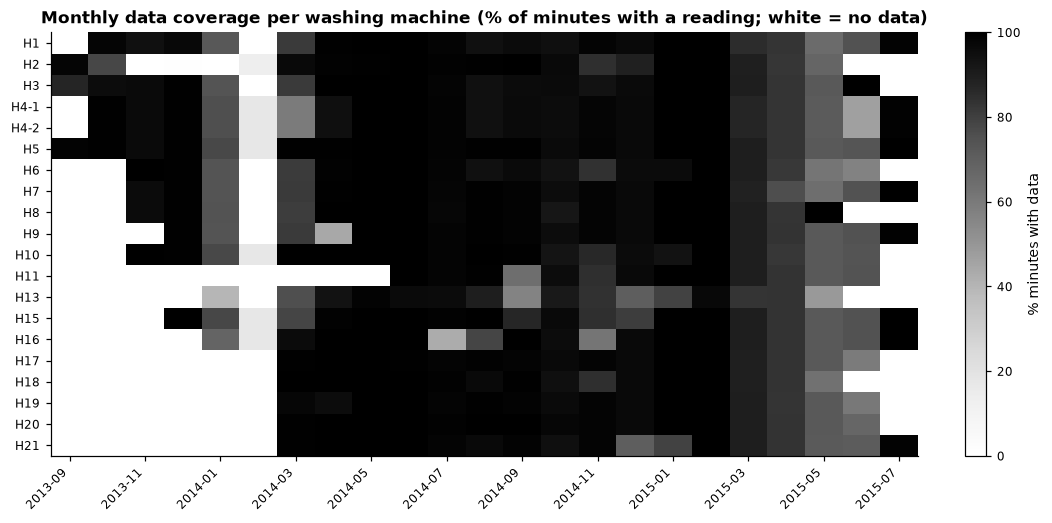

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
months = pd.period_range("2013-09", "2015-07", freq="M")
grid = []
for _, r in MACHINES.iterrows():
    have = data[r.house]["n_readings"] > 0
    mm = have.groupby(have.index.tz_convert(None).to_period("M")).mean().reindex(months)
    grid.append(mm.to_numpy() * 100)
im = ax.imshow(np.array(grid, dtype=float), aspect="auto", cmap="Greys", vmin=0, vmax=100)
ax.set_yticks(range(len(MACHINES)), MACHINES.machine)
ax.set_xticks(range(0, len(months), 2), [str(p) for p in months[::2]], rotation=45, ha="right")
ax.set_title("Monthly data coverage per washing machine (% of minutes with a reading; white = no data)")
fig.colorbar(im, ax=ax, label="% minutes with data", fraction=0.025)
ax.grid(False)
plots.save(fig, "nb02_coverage_heatmap")
plt.show()

## 2. Cycle rule

**Rule** (Kelly & Knottenbelt 2015, Table 4, ported to 1-minute samples as in Precioso &
Gómez-Ullate 2023):

* a minute is **on** when WM power ≥ **20 W**;
* **off** gaps shorter than **3 minutes** inside an activation are bridged (pauses between
  wash, rinse and spin phases);
* activations shorter than **30 minutes** are discarded (standby blips, door-lock pulses,
  short spin-only programmes);
* cycles above 3,120 W peak (13 A × 240 V, the most a plug-in appliance can draw) or longer
  than 4 h are kept but flagged as probable artefacts;
  cycles touching missing minutes are flagged and excluded from per-cycle statistics.

**Why these numbers.** 20 W is above the standby draw of every machine here and is the
threshold used across the NILM literature for washing machines (seq2point, Neural NILM,
VAE-NILM). Below I check how sensitive the cycle counts are to this choice, including
NILMTK's metadata defaults (min-on 10 min, min-off 5 min) and a data-driven threshold
(Precioso & Gómez-Ullate's k-means "middle point").

In [4]:
rules = {
    "Kelly: 20 W, off<3, on≥30 (chosen)": cycles.CycleRule(),
    "10 W threshold": cycles.CycleRule(on_threshold_w=10),
    "50 W threshold": cycles.CycleRule(on_threshold_w=50),
    "NILMTK metadata: off<5, on≥10": cycles.CycleRule(min_off_min=5, min_on_min=10),
    "off<10 (merge soak pauses)": cycles.CycleRule(min_off_min=10),
}
sens = {}
for name, rl in rules.items():
    n = 0
    for _, r in MACHINES.iterrows():
        m = data[r.house]
        n += len(cycles.detect_cycles(m[r.channel].where(m["n_readings"] > 0), rl))
    sens[name] = n
sens = pd.Series(sens, name="cycles (all machines)").to_frame()
sens["vs chosen (%)"] = (100 * (sens.iloc[:, 0] / sens.iloc[0, 0] - 1)).round(1)
sens.to_csv(C.TABLE_DIR / "nb02_rule_sensitivity.csv")
sens

,cycles (all machines),vs chosen (%)
"Kelly: 20 W, off<3, on≥30 (chosen)",6552,0.0
10 W threshold,6696,2.2
50 W threshold,6087,-7.1
"NILMTK metadata: off<5, on≥10",7499,14.5
off<10 (merge soak pauses),6565,0.2


In [5]:
thr = []
for _, r in MACHINES.iterrows():
    w = data[r.house][r.channel].dropna().to_numpy()
    w = w[w > 2]  # ignore exact zeros so k-means sees standby vs running power
    mp = cycles.kmeans_midpoint_threshold(w)
    full = data[r.house][r.channel].dropna().to_numpy()
    thr.append(
        {
            "machine": r.machine, "middle_point_W": round(mp, 0),
            "intrinsic_error_20W": round(cycles.intrinsic_error(full, full >= 20), 2),
            "intrinsic_error_middle_point": round(cycles.intrinsic_error(full, full >= mp), 2),
        }
    )
thr = pd.DataFrame(thr)
thr.to_csv(C.TABLE_DIR / "nb02_threshold_check.csv", index=False)
thr.describe().loc[["mean", "50%", "min", "max"]].round(1)

,middle_point_W,intrinsic_error_20W,intrinsic_error_middle_point
mean,1077.0,19.7,8.1
50%,1056.0,18.3,6.4
min,874.0,4.2,1.3
max,1247.0,46.5,20.6


**Reading the checks.** The k-means middle point lands in the hundreds of watts, because a
wash alternates between a ~2 kW heating phase and a 100–500 W drum phase. A threshold that high
would split every cycle into heating fragments. The *intrinsic error* (how well a two-level
on/off reconstruction explains the real power) is lower for the middle point, as Precioso &
Gómez-Ullate found, but that criterion rewards matching the heating plateau, not detecting the
whole cycle. For *cycle detection* the 20 W activation rule is the right tool; the
sensitivity table shows how much the count moves when its parameters change.

## 3. Cycle characteristics per home

In [6]:
cyc_all["local_start"] = cyc_all["start"].dt.tz_convert(C.LOCAL_TZ)
cyc_all["hour"] = cyc_all["local_start"].dt.hour
cyc_all["weekday"] = cyc_all["local_start"].dt.dayofweek
cyc_all["clean"] = (cyc_all["missing_minutes"] == 0) & ~cyc_all["too_long"] & ~cyc_all["over_max_power"]
cyc_all["heating_share"] = cyc_all["heating_kwh"] / cyc_all["energy_kwh"]
cyc_all.to_csv(C.TABLE_DIR / "nb02_cycles.csv", index=False)
good = cyc_all[cyc_all["clean"]]
SUMMARY.update(
    {
        "machines": int(len(MACHINES)), "houses": int(MACHINES.house.nunique()),
        "cycles_total": int(len(cyc_all)), "cycles_clean": int(len(good)),
        "cycles_flagged_missing": int((cyc_all["missing_minutes"] > 0).sum()),
        "cycles_flagged_too_long": int(cyc_all["too_long"].sum()),
        "cycles_flagged_over_max": int(cyc_all["over_max_power"].sum()),
    }
)
per_home = good.groupby("machine").agg(
    cycles=("energy_kwh", "size"),
    duration_min_median=("duration_min", "median"),
    duration_min_p90=("duration_min", lambda s: s.quantile(0.9)),
    peak_w_median=("peak_w", "median"),
    energy_kwh_median=("energy_kwh", "median"),
    energy_kwh_mean=("energy_kwh", "mean"),
    heating_share_median=("heating_share", "median"),
    hot_cycles_pct=("minutes_over_1500w", lambda s: 100 * (s >= 5).mean()),
).round(2)
per_home = per_home.join(quality.set_index("machine")[["cycles_per_week"]])
per_home["kwh_per_year_est"] = (per_home["energy_kwh_mean"] * per_home["cycles_per_week"] * 52).round(0)
per_home = per_home.sort_values("energy_kwh_median")
per_home.to_csv(C.TABLE_DIR / "nb02_per_home_stats.csv")
pooled = {
    "duration_min_median": float(good["duration_min"].median()),
    "duration_min_p90": float(good["duration_min"].quantile(0.9)),
    "peak_w_median": float(good["peak_w"].median()),
    "energy_kwh_median": float(good["energy_kwh"].median()),
    "energy_kwh_mean": float(good["energy_kwh"].mean()),
    "heating_share_of_energy": float(good["heating_kwh"].sum() / good["energy_kwh"].sum()),
    "cycles_per_week_median": float(quality["cycles_per_week"].median()),
}
SUMMARY["pooled"] = pooled
print({k: round(v, 3) for k, v in pooled.items()})
per_home

{'duration_min_median': 68.0, 'duration_min_p90': 118.0, 'peak_w_median': 2095.894, 'energy_kwh_median': 0.522, 'energy_kwh_mean': 0.546, 'heating_share_of_energy': 0.758, 'cycles_per_week_median': 3.96}


,cycles,duration_min_median,duration_min_p90,peak_w_median,energy_kwh_median,energy_kwh_mean,heating_share_median,hot_cycles_pct,cycles_per_week,kwh_per_year_est
machine,,,,,,,,,,
H19,239,102.0,105.0,1761.12,0.24,0.26,0.12,7.11,3.95,53.0
H5,578,46.0,104.3,2065.74,0.29,0.40,0.69,61.42,7.65,159.0
H1,414,33.0,40.0,2326.61,0.30,0.31,0.72,73.67,5.23,84.0
H18,121,49.0,68.0,2198.62,0.33,0.35,0.71,76.86,2.08,38.0
H20,204,73.0,91.0,2269.44,0.36,0.40,0.64,75.00,3.32,69.0
H17,248,52.0,68.0,2036.57,0.38,0.35,0.73,75.81,3.97,72.0
H13,376,68.0,73.0,2127.66,0.43,0.42,0.70,84.04,7.96,174.0
H11,70,103.0,115.1,2312.30,0.51,0.68,0.70,84.29,1.42,50.0
H7,900,60.0,110.0,2081.50,0.52,0.53,0.76,99.11,11.94,329.0


## 4. Plot (i): a representative day

**Why.** One concrete day shows what the disaggregation model has to do: find a multi-phase,
1–2 hour signature inside an aggregate that also contains a fridge, a kettle and everything
else. The day is chosen programmatically in a training house (House 2, no PV, no
washer-dryer): full coverage, no forward-filled flat runs, a daily aggregate energy inside
the house's inter-quartile range, and exactly one clean cycle whose energy is closest to the
house's median cycle.

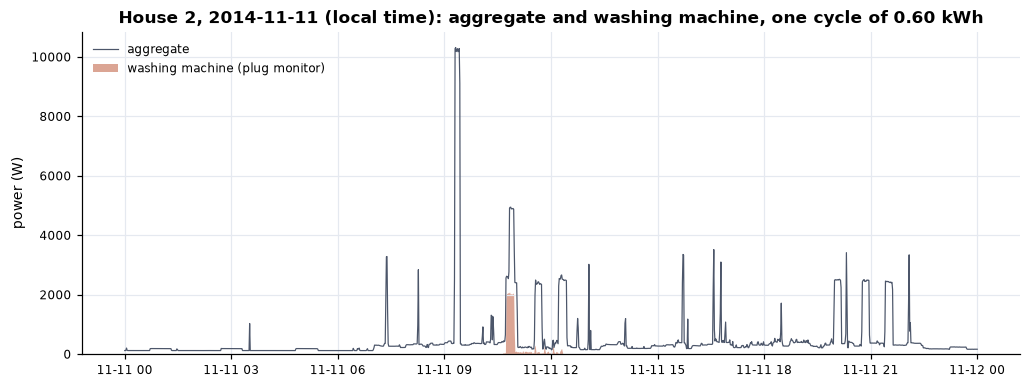

In [7]:
h_rep, ch_rep = 2, MACHINES.query("house == 2").channel.iloc[0]
c2 = good[good.house == h_rep].copy()
c2["day"] = c2["local_start"].dt.floor("D")
one = c2.groupby("day").filter(lambda g: len(g) == 1)
m2 = data[h_rep]
local_day = m2.index.tz_convert(C.LOCAL_TZ).floor("D")
cov_day = (m2["n_readings"] > 0).groupby(local_day).mean()
flat_day = pd.Series(flat_run_mask(m2["Aggregate"].where(m2["n_readings"] > 0)), index=m2.index).groupby(local_day).sum()
kwh_day = m2["Aggregate"].groupby(local_day).sum() / 60_000
lo_kwh, hi_kwh = kwh_day[cov_day >= 0.99].quantile([0.25, 0.75])
ok_day = (cov_day >= 0.99) & (flat_day == 0) & kwh_day.between(lo_kwh, hi_kwh)
one = one[one["day"].map(ok_day).fillna(False).astype(bool)]
pick = one.iloc[(one["energy_kwh"] - c2["energy_kwh"].median()).abs().argsort().iloc[0]]
d0 = pick["day"]
win = m2.loc[d0.tz_convert("UTC") : (d0 + pd.Timedelta("1D")).tz_convert("UTC")]
loc_idx = win.index.tz_convert(C.LOCAL_TZ).tz_localize(None)
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(loc_idx, win["Aggregate"], color=P["aggregate"], lw=0.8, label="aggregate")
ax.fill_between(loc_idx, 0, win[ch_rep], color=P["wm"], alpha=0.75, lw=0, label="washing machine (plug monitor)")
ax.set_ylabel("power (W)")
ax.set_title(f"House {h_rep}, {d0.date()} (local time): aggregate and washing machine, one cycle of {pick.energy_kwh:.2f} kWh")
ax.legend(loc="upper left")
ax.set_ylim(bottom=0)
plots.save(fig, "nb02_i_representative_day")
plt.show()
SUMMARY["representative_day"] = {"house": h_rep, "day": str(d0.date()), "cycle_kwh": round(float(pick.energy_kwh), 3)}

**Interpretation.** The WM cycle appears in the aggregate as a ~2 kW block (water heating)
followed by a long tail at 100–300 W with short spin peaks. On this day the heating block
coincides with a 5 kW load from another appliance, and the afternoon and evening contain
several other 2–2.5 kW blocks of the same height and similar length. That is the core
difficulty: the heating block is easy to see but not unique to the washing machine, and the
low-power tail, which carries the identity of the programme, is small next to the background.

## 5. Plot (ii): power over detected cycles

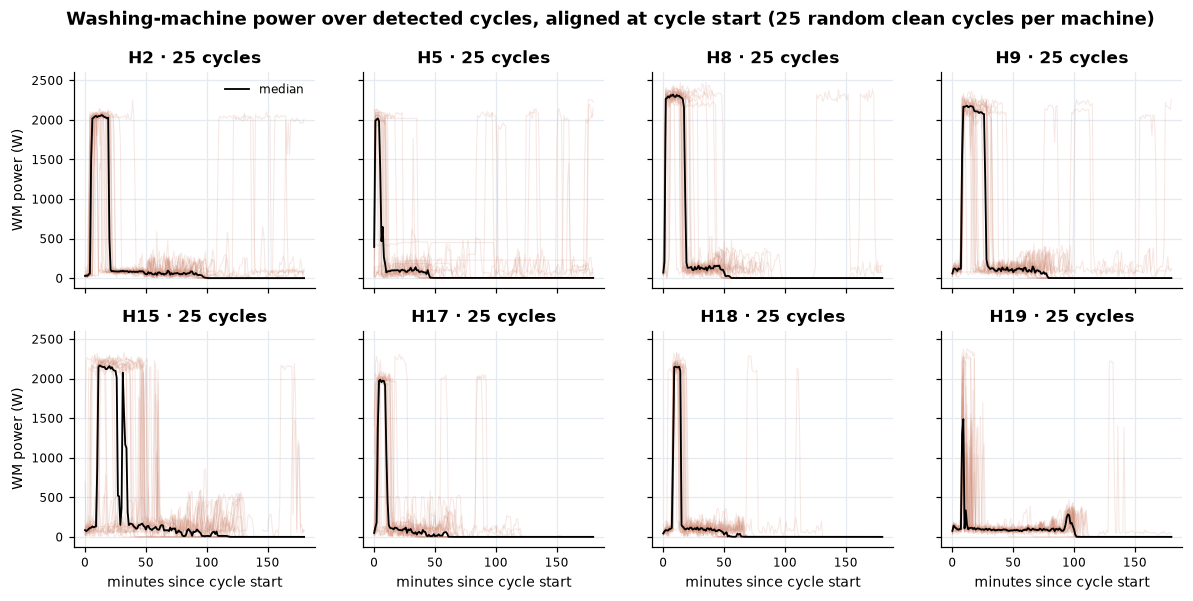

In [8]:
show = ["H2", "H5", "H8", "H9", "H15", "H17", "H18", "H19"]
fig, axes = plt.subplots(2, 4, figsize=(13, 5.6), sharex=True, sharey=True)
fig.suptitle("Washing-machine power over detected cycles, aligned at cycle start (25 random clean cycles per machine)", fontweight="bold")
for ax, mach in zip(axes.flat, show):
    row = MACHINES.set_index("machine").loc[mach]
    s = data[int(row.house)][row.channel]
    cc = good[good.machine == mach].sample(n=min(25, (good.machine == mach).sum()), random_state=0)
    prof = []
    for _, c in cc.iterrows():
        seg = s.loc[c.start : c.start + pd.Timedelta("180min")].to_numpy()
        seg = np.r_[seg, np.full(181 - len(seg), np.nan)][:181]
        prof.append(seg)
        ax.plot(np.arange(181), seg, color=P["wm"], alpha=0.18, lw=0.7)
    ax.plot(np.arange(181), np.nanmedian(np.array(prof), axis=0), color="black", lw=1.2, label="median")
    ax.set_title(f"{mach} · {len(cc)} cycles")
for ax in axes[1]:
    ax.set_xlabel("minutes since cycle start")
for ax in axes[:, 0]:
    ax.set_ylabel("WM power (W)")
axes[0, 0].legend()
plots.save(fig, "nb02_ii_cycles_overlay")
plt.show()

**Interpretation.** Most machines share the same shape: an early ~2 kW heating plateau lasting
10–25 minutes, a long agitation phase at a few hundred watts, and spin bursts near the end.
Homes differ in *how often* the heating plateau appears (cold washes skip it) and in total
length (programme choice). That variability within a home is as large as the variability
between homes, which is why a model has to generalise across programmes, not just across houses.

## 6. Plot (iii): when washing happens

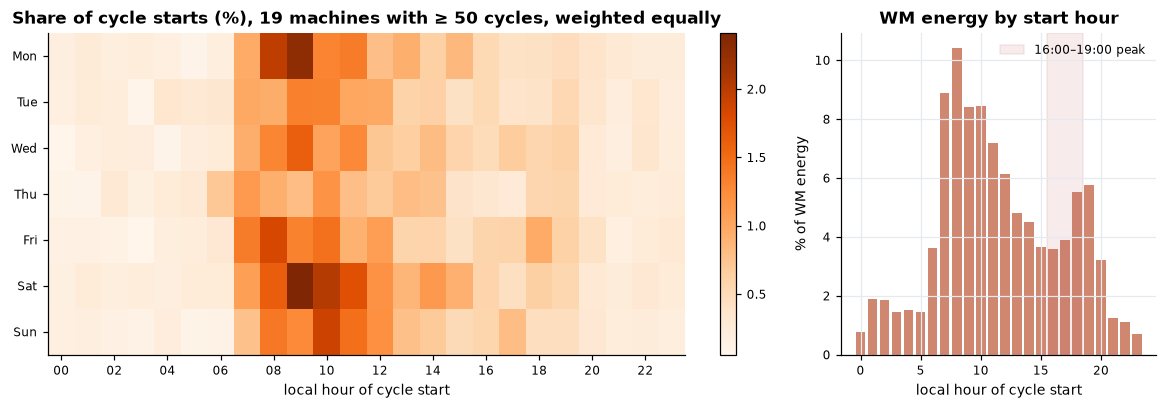

{'weekend_share_of_cycles_pct': np.float64(32.6),
 'weekend_days_share_pct': 28.6,
 'peak_16_19_share_of_cycles_pct': np.float64(12.9),
 'peak_16_19_share_of_energy_pct': np.float64(13.0),
 'weekday_peak_16_19_share_of_energy_pct': np.float64(9.2),
 'morning_7_12_share_of_cycles_pct': np.float64(44.2),
 'night_22_7_share_of_cycles_pct': np.float64(12.2)}

In [9]:
# machines with >= 50 clean cycles weighted equally (a machine with a handful of cycles would
# otherwise dominate single cells of the heat map)
n_clean = good.groupby("machine")["energy_kwh"].transform("size")
busy = good[n_clean >= 50]
w8 = busy.groupby("machine")["energy_kwh"].transform(lambda s: 1 / len(s))
heat = busy.assign(w=w8).pivot_table(index="weekday", columns="hour", values="w", aggfunc="sum").reindex(index=range(7), columns=range(24)).fillna(0)
heat = 100 * heat / heat.to_numpy().sum()
energy_hour = good.assign(w=good["energy_kwh"]).groupby("hour")["w"].sum().reindex(range(24), fill_value=0)
energy_hour = 100 * energy_hour / energy_hour.sum()
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [2.2, 1]})
im = axes[0].imshow(heat.to_numpy(), aspect="auto", cmap="Oranges")
axes[0].set_yticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[0].set_xticks(range(0, 24, 2), [f"{h:02d}" for h in range(0, 24, 2)])
axes[0].set_xlabel("local hour of cycle start")
axes[0].set_title(f"Share of cycle starts (%), {busy.machine.nunique()} machines with ≥ 50 cycles, weighted equally")
axes[0].grid(False)
fig.colorbar(im, ax=axes[0], fraction=0.03)
axes[1].bar(range(24), energy_hour.to_numpy(), color=P["wm"])
axes[1].axvspan(15.5, 18.5, color=P["flag"], alpha=0.12, label="16:00–19:00 peak")
axes[1].set_xlabel("local hour of cycle start")
axes[1].set_ylabel("% of WM energy")
axes[1].set_title("WM energy by start hour")
axes[1].legend()
plots.save(fig, "nb02_iii_usage_by_hour_day")
plt.show()

wk = good["weekday"] >= 5
peak = good["hour"].between(16, 18)
timing = {
    "weekend_share_of_cycles_pct": round(100 * wk.mean(), 1),
    "weekend_days_share_pct": round(100 * 2 / 7, 1),
    "peak_16_19_share_of_cycles_pct": round(100 * peak.mean(), 1),
    "peak_16_19_share_of_energy_pct": round(100 * good.loc[peak, "energy_kwh"].sum() / good["energy_kwh"].sum(), 1),
    "weekday_peak_16_19_share_of_energy_pct": round(100 * good.loc[peak & ~wk, "energy_kwh"].sum() / good["energy_kwh"].sum(), 1),
    "morning_7_12_share_of_cycles_pct": round(100 * good["hour"].between(7, 11).mean(), 1),
    "night_22_7_share_of_cycles_pct": round(100 * ((good["hour"] >= 22) | (good["hour"] < 7)).mean(), 1),
}
SUMMARY["timing"] = timing
timing

## 7. Plot (iv): cycle energy and duration across homes

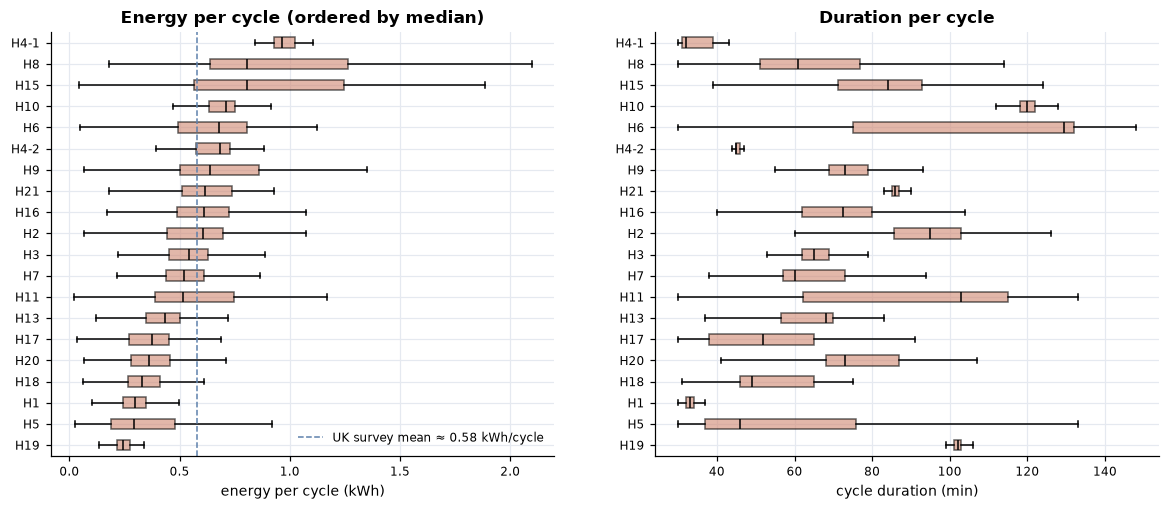

In [10]:
order = per_home.index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, lab in [(axes[0], "energy_kwh", "energy per cycle (kWh)"), (axes[1], "duration_min", "cycle duration (min)")]:
    vals = [good.loc[good.machine == mch, col].to_numpy() for mch in order]
    bp = ax.boxplot(vals, orientation="horizontal", tick_labels=order, showfliers=False, patch_artist=True, medianprops={"color": "black"})
    for b in bp["boxes"]:
        b.set_facecolor(P["wm"])
        b.set_alpha(0.6)
    ax.set_xlabel(lab)
axes[0].axvline(0.58, color=P["pred"], ls="--", lw=1, label="UK survey mean ≈ 0.58 kWh/cycle")
axes[0].legend(loc="lower right")
axes[0].set_title("Energy per cycle (ordered by median)")
axes[1].set_title("Duration per cycle")
plots.save(fig, "nb02_iv_cycle_energy_duration_by_home")
plt.show()

**Reference line.** The UK Household Electricity Survey (Zimmermann et al. 2012, 250 homes)
measured ~284 cycles a year and ~166 kWh a year per washing machine, i.e. about 0.58 kWh per
cycle; the dashed line is that benchmark.

## 8. Heating energy: the lever behind most of the consumption

**Why.** Heating water is the only high-power phase of a wash. If most WM energy is heating,
the most effective saving lever is the wash temperature, not the timing.

In [11]:
heat_tab = pd.DataFrame(
    {
        "share_of_WM_energy_in_heating_minutes_pct": [round(100 * pooled["heating_share_of_energy"], 1)],
        "cycles_with_heating_ge5min_pct": [round(100 * (good["minutes_over_1500w"] >= 5).mean(), 1)],
        "median_kwh_hot_cycles": [round(good.loc[good["minutes_over_1500w"] >= 5, "energy_kwh"].median(), 3)],
        "median_kwh_cold_cycles": [round(good.loc[good["minutes_over_1500w"] < 5, "energy_kwh"].median(), 3)],
    }
)
SUMMARY["heating"] = heat_tab.iloc[0].to_dict()
heat_tab

,share_of_WM_energy_in_heating_minutes_pct,cycles_with_heating_ge5min_pct,median_kwh_hot_cycles,median_kwh_cold_cycles
0,75.8,85.7,0.566,0.193


## 9. Save outputs

In [12]:
with open(C.METRIC_DIR / "nb02_summary.json", "w") as fh:
    json.dump(SUMMARY, fh, indent=2, default=str)
print(json.dumps(SUMMARY, indent=1, default=str)[:1500])

{
 "machines": 20,
 "houses": 19,
 "cycles_total": 6552,
 "cycles_clean": 6334,
 "cycles_flagged_missing": 182,
 "cycles_flagged_too_long": 40,
 "cycles_flagged_over_max": 0,
 "pooled": {
  "duration_min_median": 68.0,
  "duration_min_p90": 118.0,
  "peak_w_median": 2095.894444444444,
  "energy_kwh_median": 0.5216165277777778,
  "energy_kwh_mean": 0.5460873943027365,
  "heating_share_of_energy": 0.7577894684902121,
  "cycles_per_week_median": 3.96
 },
 "representative_day": {
  "house": 2,
  "day": "2014-11-11",
  "cycle_kwh": 0.601
 },
 "timing": {
  "weekend_share_of_cycles_pct": 32.6,
  "weekend_days_share_pct": 28.6,
  "peak_16_19_share_of_cycles_pct": 12.9,
  "peak_16_19_share_of_energy_pct": 13.0,
  "weekday_peak_16_19_share_of_energy_pct": 9.2,
  "morning_7_12_share_of_cycles_pct": 44.2,
  "night_22_7_share_of_cycles_pct": 12.2
 },
 "heating": {
  "share_of_WM_energy_in_heating_minutes_pct": 75.8,
  "cycles_with_heating_ge5min_pct": 85.7,
  "median_kwh_hot_cycles": 0.566,
  "med

## Summary

**Coverage.** 19 of 20 homes have a washing-machine monitor (House 12 has none); House 4 has
two machines, so 20 machines are analysed. Records span 13–21 months per home (Sep 2013 – Jul
2015) with 75–94 % of minutes holding a reading. Outages appear in the cleaned release either
as missing rows or as forward-filled flat lines, and both are treated as missing.

**Cycles.** With the 20 W / 3-minute / 30-minute activation rule, 6,552 cycles are detected,
6,334 of them clean (182 touch missing data, 40 last over 4 hours). The count changes by
+2 % at 10 W, −7 % at 50 W and +14 % with NILMTK's metadata defaults; merging pauses of up to
10 minutes changes it by only 0.2 %, so cycles are rarely split. The rule captures 80–99 % of
each machine's energy (House 4 is the exception).

| | median (pooled) |
|---|---|
| duration | 68 min (90th percentile 118 min) |
| peak power | 2.1 kW |
| energy per cycle | 0.52 kWh (mean 0.55; UK survey benchmark ≈ 0.58) |
| cycles per week | 4.0 (range 1.4–11.9 across machines) |

**Patterns.** Washing is a morning activity: 44 % of cycles start between 07:00 and 12:00,
with peaks on Monday and Saturday mornings. Weekends hold 33 % of cycles against 29 % of days.
Only 13 % of cycles and 13 % of WM energy start in the 16:00–19:00 network peak.

**Where the energy goes.** 76 % of WM energy is drawn in minutes above 1.5 kW, i.e. water
heating. 86 % of cycles heat for at least 5 minutes; a heated cycle uses a median 0.57 kWh, an
unheated one 0.19 kWh. Homes differ mostly in this choice: House 19 runs mainly unheated
cycles at 0.24 kWh, House 15 heated ones at 0.81 kWh.

**Implications for modelling.**
* The WM is off in 91–99.7 % of valid minutes, so the target is extremely sparse: an
  always-zero predictor already has a small MAE, which is why active-period and cycle
  metrics are needed.
* A cycle lasts up to about 2 hours (P90 = 118 min); a window of about 2 × P90 ≈ 237 minutes
  gives the model a whole cycle of context on either side of the predicted minute.
* The 2 kW heating block is not unique to the WM (kettles, dishwashers, washer-dryers and
  showers draw similar power), so false detections are expected around those appliances.

## Verification log

* Visual: the representative-day figure shows a single washing-machine block on the selected day
  (cycle energy 0.60 kWh from the cycle table), and the overlay panels show the same
  heating-then-tail shape across machines.
* Found and fixed three problems during review: (1) Kelly's 2,500 W maximum flagged the
  2.55 kW heaters in House 4 as artefacts, so the flag now uses the 13 A plug limit;
  (2) equal weighting let a machine with a single clean cycle dominate one cell of the heat
  map, so only machines with ≥ 50 cycles are weighted; (3) the first "representative" day sat
  inside a forward-filled outage, so flat runs now disqualify a day.
* The pooled mean cycle energy (0.55 kWh) is within 6 % of the UK Household Electricity
  Survey's 0.58 kWh, an independent sanity check on both the data and the cycle rule.

**Next:** `03_modeling_dataset_and_splits` turns these findings into the data contract for
the disaggregation model.